In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "careamics[examples]>=0.0.15",
# ]
# ///

<a href="https://ai4life-mdc24.grand-challenge.org/ai4life-mdc24/">
    <img src="https://rumc-gcorg-p-public.s3.amazonaws.com/b/756/denoising.x10.jpeg" height="200" />
</a>

# JUMP dataset

In [2]:
# Imports necessary to execute the code
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pooch
import tifffile
from careamics import CAREamist
from careamics.config import create_n2v_config
from careamics.utils.get_device import get_device

# use n2v2
use_n2v2 = False

# folder in which to save all the data
root = Path("jump")

## Import the dataset

In [3]:
# download the data using pooch
data_root = root / "data"
dataset_url = "https://zenodo.org/records/10912386/files/noisy.tiff"

file = pooch.retrieve(
    url=dataset_url,
    known_hash="394541cd10b5f10cc929e8083e42f757e47eb0a318cf78448a9e4622179c3069",
    path=data_root,
)

## Visualize data

Image shape: (517, 4, 540, 540)


Text(0.5, 1.0, 'Channel 4')

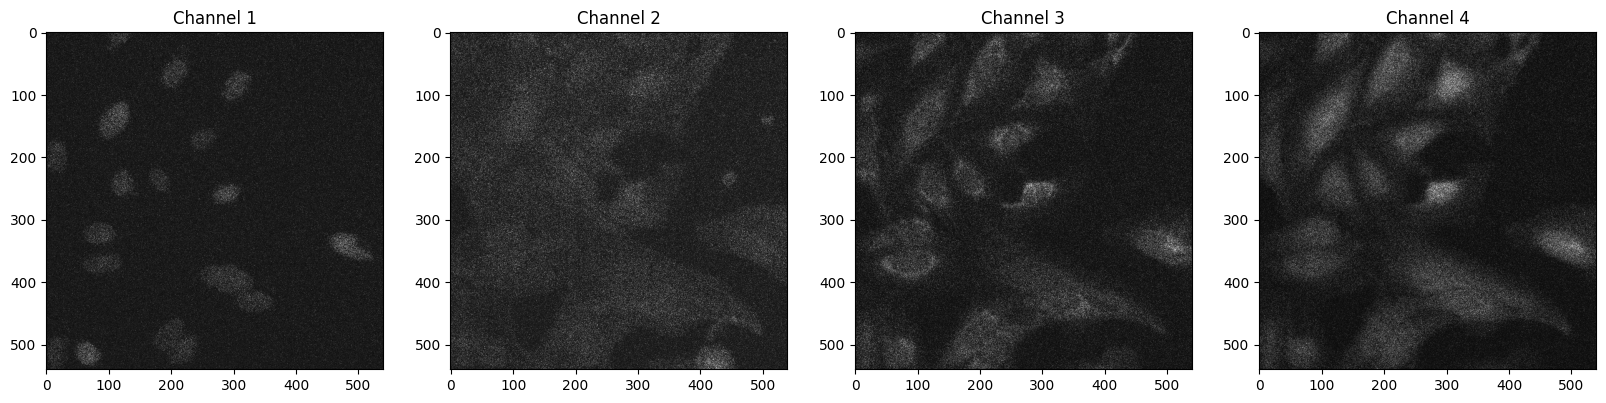

In [4]:
# load training and validation image and show them side by side
train_image = tifffile.imread(file)
print(f"Image shape: {train_image.shape}")

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(train_image[0][0], cmap="gray")
ax[0].set_title("Channel 1")
ax[1].imshow(train_image[0][1], cmap="gray")
ax[1].set_title("Channel 2")
ax[2].imshow(train_image[0][2], cmap="gray")
ax[2].set_title("Channel 3")
ax[3].imshow(train_image[0][3], cmap="gray")
ax[3].set_title("Channel 4")

## Train with CAREamics

### Create configuration


In [5]:
# create configuration
algo = "n2v2" if use_n2v2 else "n2v"

config = create_n2v_config(
    experiment_name="jump_" + algo,
    data_type="array",
    axes="SCYX",
    patch_size=(64, 64),
    batch_size=32,
    num_epochs=15,
    n_channels=4,
    use_n2v2=use_n2v2,
)

print(config)

{'algorithm_config': {'algorithm': 'n2v',
                      'loss': 'n2v',
                      'lr_scheduler': {'name': 'ReduceLROnPlateau',
                                       'parameters': {}},
                      'model': {'architecture': 'UNet',
                                'conv_dims': 2,
                                'depth': 2,
                                'final_activation': 'None',
                                'in_channels': 4,
                                'independent_channels': True,
                                'n2v2': False,
                                'num_channels_init': 32,
                                'num_classes': 4,
                                'residual': False,
                                'use_batch_norm': True},
                      'monitor_metric': 'val_loss',
                      'n2v_config': {'masked_pixel_percentage': 0.2,
                                     'name': 'N2VManipulate',
                              

### Train

In [7]:
# instantiate a CAREamist
careamist = CAREamist(config=config)
# train
careamist.train(train_data=train_image)

No working directory provided. Using current working directory: /home/diya.srivastava/Desktop/repos/careamics-examples/applications/n2v/channels.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Seed set to 432011014
You are using a CUDA device ('NVIDIA A40-24Q') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Computing mean/std statistics: 100%|██████████| 37224/37224 [00:09<00:00, 3794.50it/s]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | model   | UNet             | 1.3 M  | train
1 | metrics | MetricCollection | 0      | train
-----------------------------------------------------
1.3 M     Train

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


## Predict 

In [10]:
prediction, source = careamist.predict(
    pred_data=train_image,
    tile_size=(256, 256),
    tile_overlap=(48, 48),
    batch_size=1,
)

/home/diya.srivastava/Desktop/repos/careamics/.venv/lib/python3.12/site-packages/pydantic/main.py:114: UserWarning: Warning: Batch normalization is used with batch size 1. We advise using a batch size of at least 8 when using batch normalization, as smaller batch sizes may be unreliable. Consider increasing the batch size or disabling batch normalization in the algorithm `model` parameter.
  'validate_assignment': lambda model, name, val: model.__pydantic_validator__.validate_assignment(model, name, val),  # pyright: ignore[reportAssignmentType]
Creating prediction output directory: '/home/diya.srivastava/Desktop/repos/careamics-examples/applications/n2v/channels'
Restoring states from the checkpoint path at /home/diya.srivastava/Desktop/repos/careamics-examples/applications/n2v/channels/checkpoints/jump_n2v_0/jump_n2v_last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/diya.srivastava/Desktop/repos/careamics-examples/applications/n2v/c

Predicting: |          | 0/? [00:00<?, ?it/s]

### Save predictions

In [11]:
pred_folder = root / ("results_" + algo)
pred_folder.mkdir(exist_ok=True, parents=True)

final_data = np.concatenate(prediction)
tifffile.imwrite(pred_folder / "prediction.tiff", final_data)

### Visualize the prediction

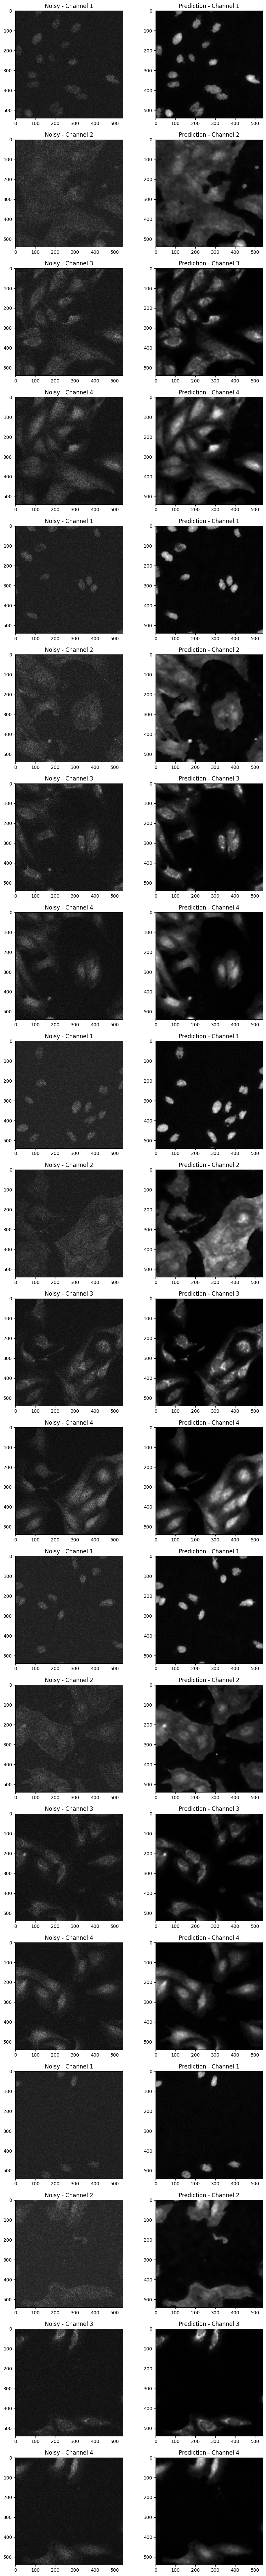

In [14]:
pred_array = prediction[0]  # shape (S, C, Y, X)

n = 5
fig, ax = plt.subplots(4 * n, 2, figsize=(10, 4 * n * 5))
for i in range(n):
    row = 4 * i
    for ch in range(4):
        ax[row + ch, 0].imshow(train_image[i, ch], cmap="gray")
        ax[row + ch, 0].set_title(f"Noisy - Channel {ch + 1}")
        ax[row + ch, 1].imshow(pred_array[i, ch], cmap="gray")
        ax[row + ch, 1].set_title(f"Prediction - Channel {ch + 1}")

## Create cover

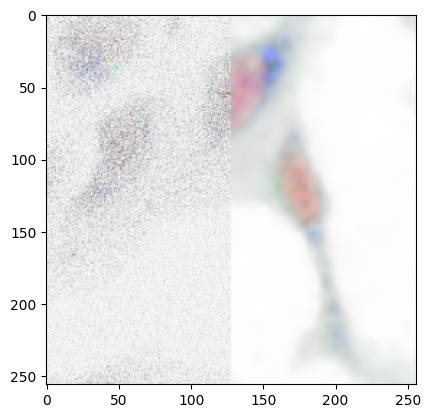

In [16]:
# create a cover image
im_idx = 9
cv_image_noisy = train_image[im_idx]
cv_image_pred = prediction[0][im_idx]

# create image
cover = np.zeros((4, 256, 256))
(_, height, width) = cv_image_noisy.shape
assert height > 256
assert width > 256

# get min and max and reshape them so that they can be broadcasted with the images
noise_min = np.array(np.min(cv_image_noisy, axis=(1, 2)))[
    (..., *[np.newaxis] * (cv_image_noisy.ndim - 1))
]
noise_max = np.array(np.max(cv_image_noisy, axis=(1, 2)))[
    (..., *[np.newaxis] * (cv_image_noisy.ndim - 1))
]
pred_min = np.array(np.min(cv_image_pred, axis=(1, 2)))[
    (..., *[np.newaxis] * (cv_image_pred.ndim - 1))
]
pred_max = np.array(np.max(cv_image_pred, axis=(1, 2)))[
    (..., *[np.newaxis] * (cv_image_pred.ndim - 1))
]

# normalize train and prediction per channel
norm_noise = (cv_image_noisy - noise_min) / (noise_max - noise_min)
norm_pred = (cv_image_pred - pred_min) / (pred_max - pred_min)

# fill in halves
cover[:, :, : 256 // 2] = norm_noise[
    :,
    height // 2 - 256 // 2 : height // 2 + 256 // 2,
    width // 2 - 256 // 2 : width // 2,
]
cover[:, :, 256 // 2 :] = norm_pred[
    :,
    height // 2 - 256 // 2 : height // 2 + 256 // 2,
    width // 2 : width // 2 + 256 // 2,
]

# move C axis at the end
cover = np.moveaxis(cover, 0, -1)

# plot the single image
plt.imshow(cover)

# save the image
plt.imsave("JUMP_N2V.jpeg", cover)